# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [12]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [42]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 217
X shape: (331, 122)
y shape: (331,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [14]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [15]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [16]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

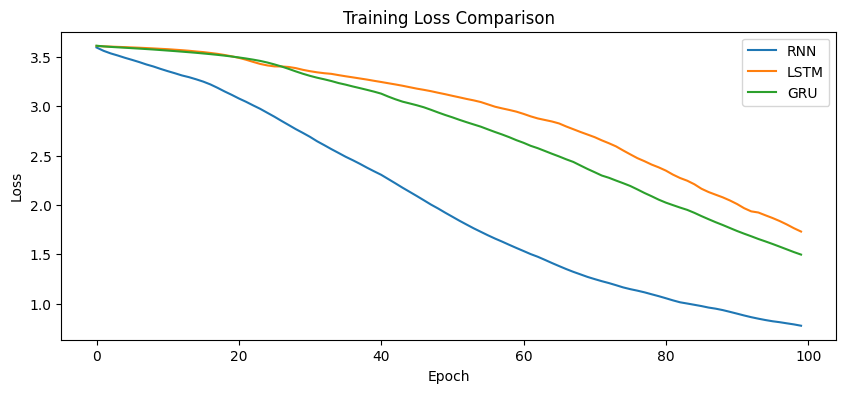

In [17]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [18]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [19]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning learning models artificial meaningful sentences
GRU : deep learning is faster and next lstm


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ***Task 1 : Replace corpus with your own paragraph***

In [41]:
corpus = '''
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.

High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.

The traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for robotics.[a] To reach these goals, AI researchers have used techniques including state space search and mathematical optimization, formal logic, artificial neural networks, and methods based on statistics, operations research, and economics.[b] AI also draws upon psychology, linguistics, philosophy, neuroscience, and other fields. Some companies, such as OpenAI, Google DeepMind and Meta, aim to create artificial general intelligence (AGI) – AI that can complete virtually any cognitive task at least as well as a human.

Artificial intelligence was founded as an academic discipline in 1956, and the field went through multiple cycles of optimism throughout its history,followed by periods of disappointment and loss of funding, known as AI winters.Funding and interest increased substantially after 2012, when graphics processing units began being used to accelerate neural networks, and deep learning outperformed previous AI techniques.This growth accelerated further after 2017 with the transformer architecture.In the 2020s, an AI boom has coincided with advances in generative AI, which allowed for the creation and modification of media. In addition to AI safety and unintended consequences and harms from the use of AI, ethical concerns, AI's long-term effects, and potential existential risks have prompted discussions of AI regulation.
'''
print(corpus)


Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.

High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.

The traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for robotics.[a] To reach these goals, A

# ***Task 2 , 3 & 4 : Increase embedding dimension ,Increase epochs to 200 , Change hidden units 64 → 128***

# **Model 1 : Vanila RNN**

In [43]:
rnn_model1 = Sequential([
    Embedding(total_words, 64), # Task 2: Increased from 32 to 64
    SimpleRNN(128),              # Task 4: Changed from 64 to 128
    Dense(total_words, activation='softmax')
])

rnn_model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Task 3: Increased epochs from 100 to 200
rnn_history1 = rnn_model1.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# **Model 2 : LSTM Model**

In [44]:
lstm_model1 = Sequential([
    Embedding(total_words, 64), # Task 2: Increased from 32 to 64
    LSTM(128),                   # Task 4: Changed from 64 to 128
    Dense(total_words, activation='softmax')
])

lstm_model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Task 3: Increased epochs from 100 to 200
lstm_history1 = lstm_model1.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# **Model 3 : GRU**

In [45]:
gru_model1 = Sequential([
    Embedding(total_words, 64), # Task 2: Increased from 32 to 64
    GRU(128),                    # Task 4: Changed from 64 to 128
    Dense(total_words, activation='softmax')
])

gru_model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Task 3: Increased epochs from 100 to 200
gru_history1 = gru_model1.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


# **Compare Training Loss**

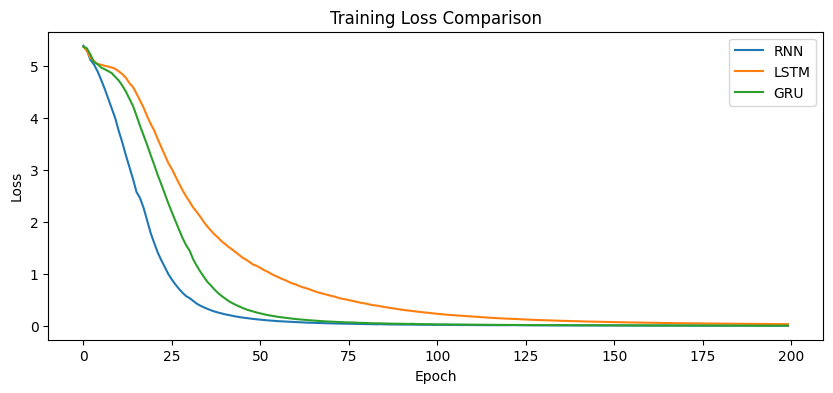

In [46]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history1.history['loss'], label='RNN')
plt.plot(lstm_history1.history['loss'], label='LSTM')
plt.plot(gru_history1.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ***Task 5 : Generate 10 words instead of 5***

In [ ]:

print("RNN :", generate_text(rnn_model1, "artificial intelligence", 10))
print("LSTM:", generate_text(lstm_model1, "artificial intelligence", 10))
print("GRU :", generate_text(gru_model1, "artificial intelligence", 10))

RNN : artificial intelligence ai is the capability of computational systems to perform tasks
LSTM: artificial intelligence ai is the capability of computational systems to perform tasks
GRU : artificial intelligence ai is the capability of computational systems to perform tasks


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**